# Clinical Trials EDA
Exploratory analysis of cleaned studies from `clinical_trials.db`.

In [284]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from query import load_all

plt.rcParams.update({
    "figure.figsize":    (6.5, 3.5),  # matches \textwidth on letter with 1in margins
    "figure.dpi":        150,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.titlesize":  14,
})

df = load_all()
print(f"{len(df):,} studies loaded")
df.head(3)

df = df[df['phase2'] == True]
print(f"{len(df):,} phase 2 studies")

print("All INTERVENTIONAL:", all(df['study_type'] == 'INTERVENTIONAL'))

89 studies loaded
42 phase 2 studies
All INTERVENTIONAL: True


## Status breakdown

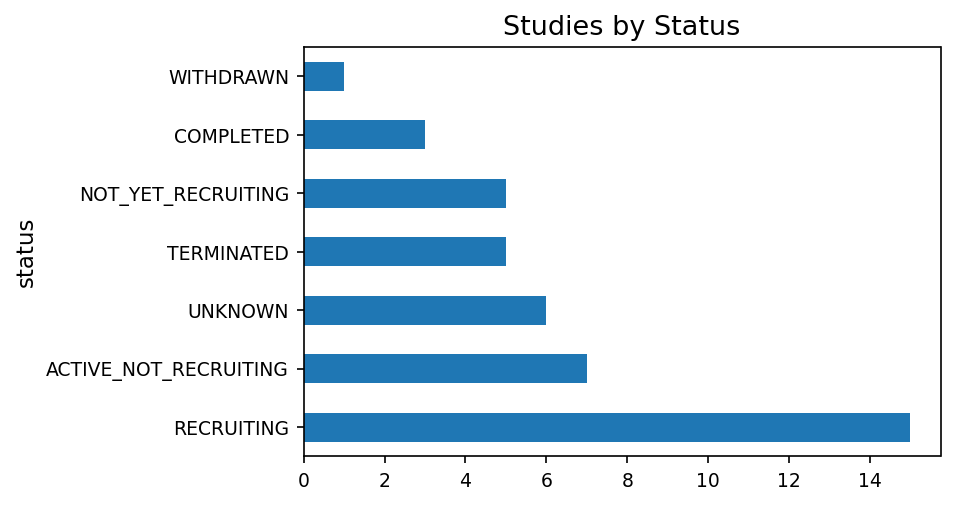

In [279]:
df['status'].value_counts().plot(kind='barh', title='Studies by Status')
plt.tight_layout()
plt.savefig('../figures/fig_status.png')
plt.show()

## Phase distribution

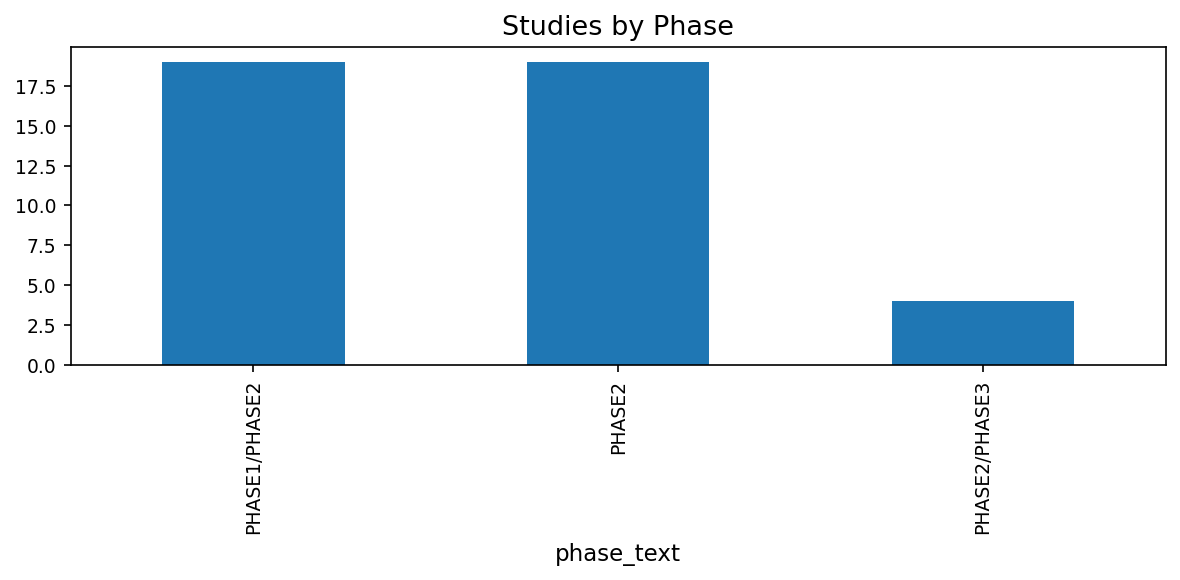

In [268]:
phase_order = ['EARLY_PHASE1', 'PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'NA', 'missing']
# assert set(df['phase_text'].dropna().unique()).issubset(set(phase_order)), "Unexpected phase values found"
# assert set(phase_order).issubset(set(df['phase_text'].fillna('missing').unique())), "Phase order contains values not found in data"

counts = df['phase_text'].fillna('missing').value_counts()
counts = counts.reindex([p for p in phase_order if p in counts.index])

counts.plot(kind='bar', figsize=(8, 4), title='Studies by Phase')
plt.tight_layout()
plt.show()

## Enrollment histogram

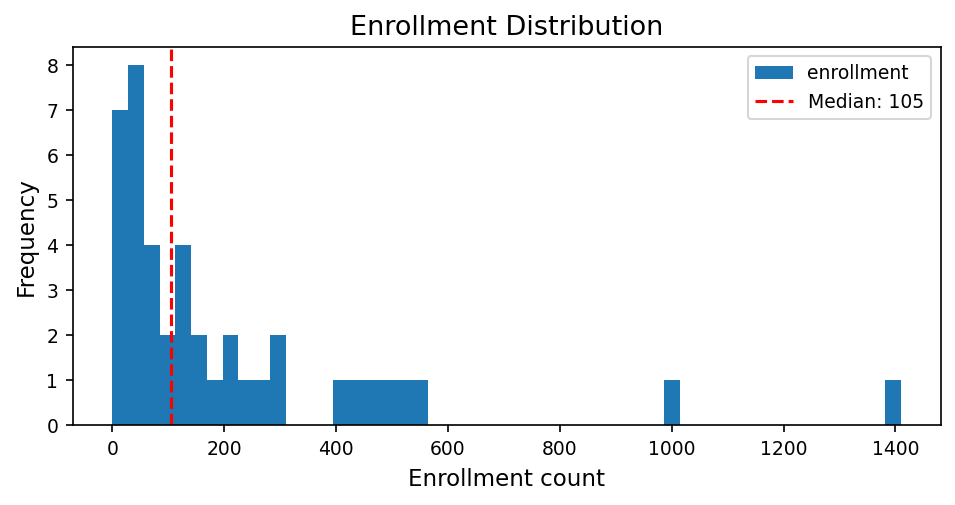

count      42.000000
mean      205.047619
std       280.012104
min         0.000000
25%        30.250000
50%       105.000000
75%       254.000000
max      1410.000000
Name: enrollment, dtype: float64
Number of studies with 0 enrollment: 1


In [269]:
enrollment = df['enrollment'].dropna()
median_enrollment = enrollment.median()

ax = enrollment.plot(
    kind='hist', bins=50, #figsize=(8, 4),
    title='Enrollment Distribution'
)
ax.axvline(median_enrollment, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_enrollment:.0f}')
ax.legend()
plt.xlabel('Enrollment count')
plt.tight_layout()
# plt.savefig('../figures/fig_enrollment.png')
plt.show()
print(enrollment.describe())
print(f"Number of studies with 0 enrollment: {(enrollment == 0).sum()}")

## Trials opened per year

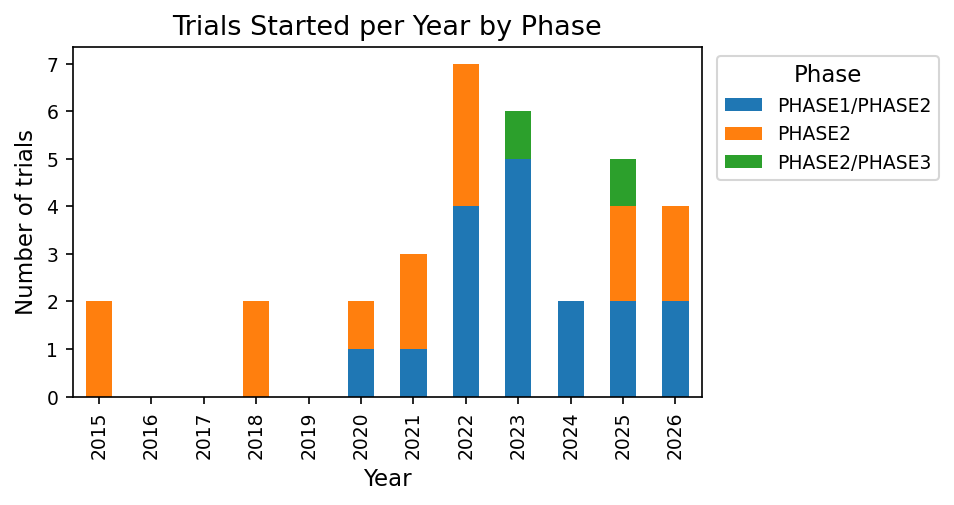

In [271]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year

by_year_phase = (
    df
    .groupby(['start_year', df['phase_text'].fillna('missing')])
    .size()
    .unstack(fill_value=0)
)

all_years = range(int(by_year_phase.index.min()), int(by_year_phase.index.max()) + 1)
by_year_phase = by_year_phase.reindex(all_years, fill_value=0)

by_year_phase.plot(kind='bar', stacked=True, title='Trials Started per Year by Phase')
plt.xlabel('Year')
plt.ylabel('Number of trials')
plt.legend(title='Phase', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/fig_byYearPhase.png')
plt.show()

## Geographic breakdown — trials by country

21 unique countries


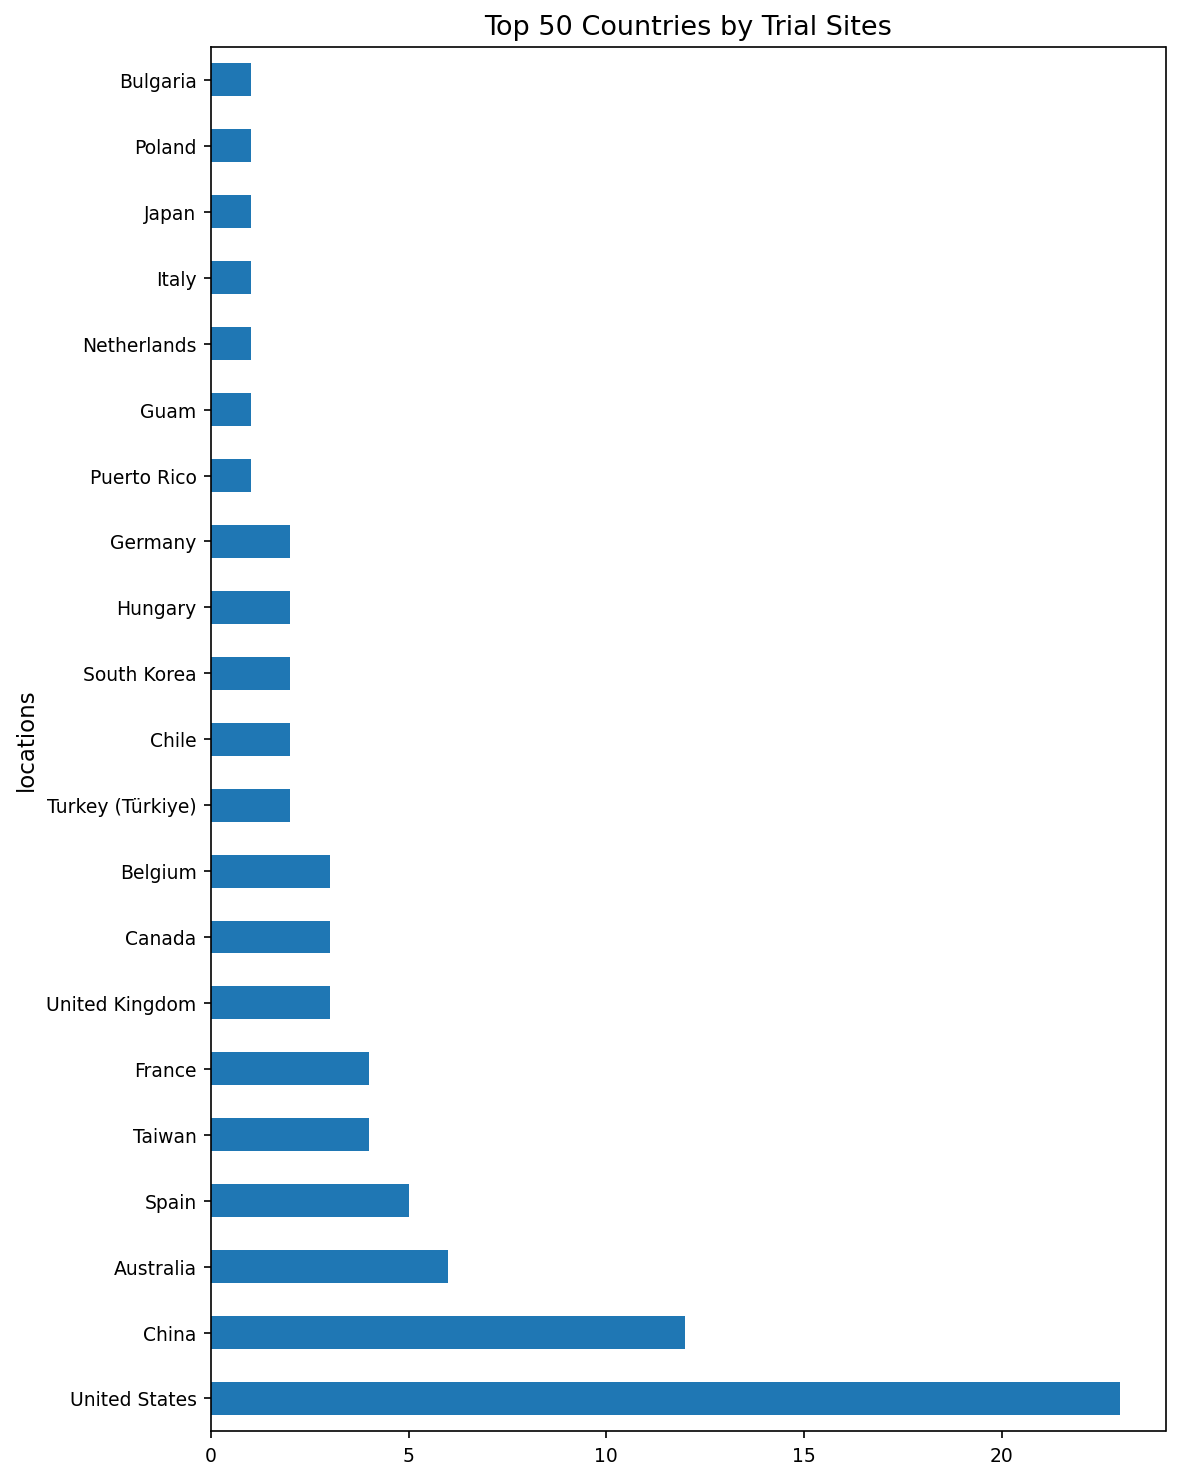

In [243]:
# Each study can have many locations — explode them out
locs = df['locations'].dropna().apply(json.loads)
study_countries = locs.apply(lambda loc_set: {loc.get('country') for loc in loc_set}) # set of countries per study, so a country can only be counted once per study
countries = set(study_countries.explode().dropna()) # nan come from missing locations, many are widthdrawn studies with no locations
print(len(countries), "unique countries")
study_countries.explode().value_counts().head(50).plot(
    kind='barh', figsize=(8, 10), title='Top 50 Countries by Trial Sites'
)
plt.tight_layout()
plt.show()

## Geographic breakdown — US trials by state

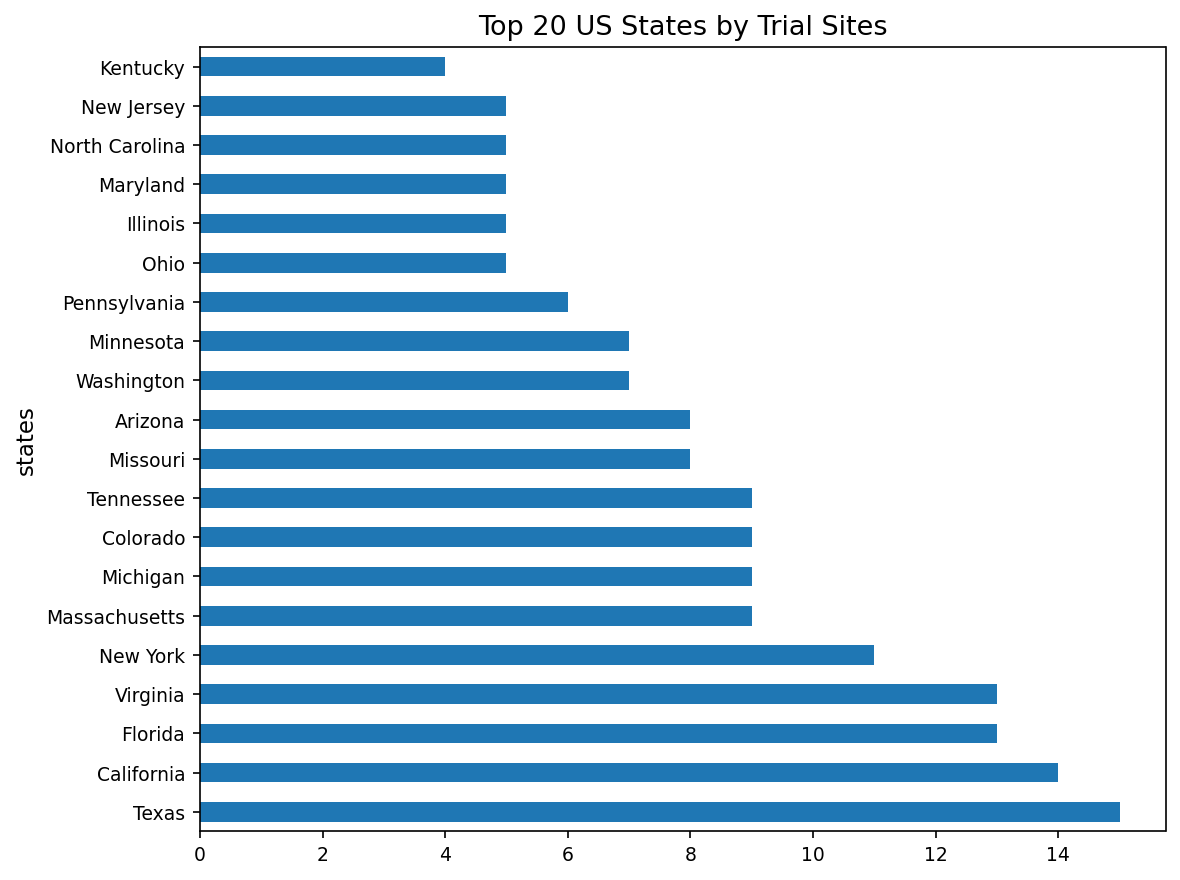

In [244]:
locs = df['locations'].dropna().apply(json.loads)
locs = locs.to_frame(name='json')
locs['countries'] = locs.apply(lambda row: {loc.get('country') for loc in row['json']}, axis=1)
locs['states'] = locs.apply(lambda row: {loc.get('state') for loc in row['json']}, axis=1)

# normalized trials with multiple sites in same state
us = locs[locs['countries'].apply(lambda x: 'United States' in x)].dropna(subset=['states'])
us['states'].explode().value_counts().head(20).plot(
    kind='barh', figsize=(8, 6), title='Top 20 US States by Trial Sites'
)
plt.tight_layout()
plt.show()

# Sites in EU and US

In [245]:
euAndUs_contries = [
    "Austria",
    "Belgium",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Netherlands",
    "Poland",
    "Portugal",
    "Romania",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "United States"
]

eu = locs[locs['countries'].apply(lambda x: any(c in euAndUs_contries for c in x))]
print(len(eu), "studies with EU or US sites")

# sites = pd.json_normalize(df['locations'].dropna().apply(json.loads).explode())
# print(sites.shape, sites.head())

# print(len(eu), "studies with EU sites")
# print(eu['countries'])

26 studies with EU or US sites


## Sponsor class breakdown

Number of unique sponsors: 36


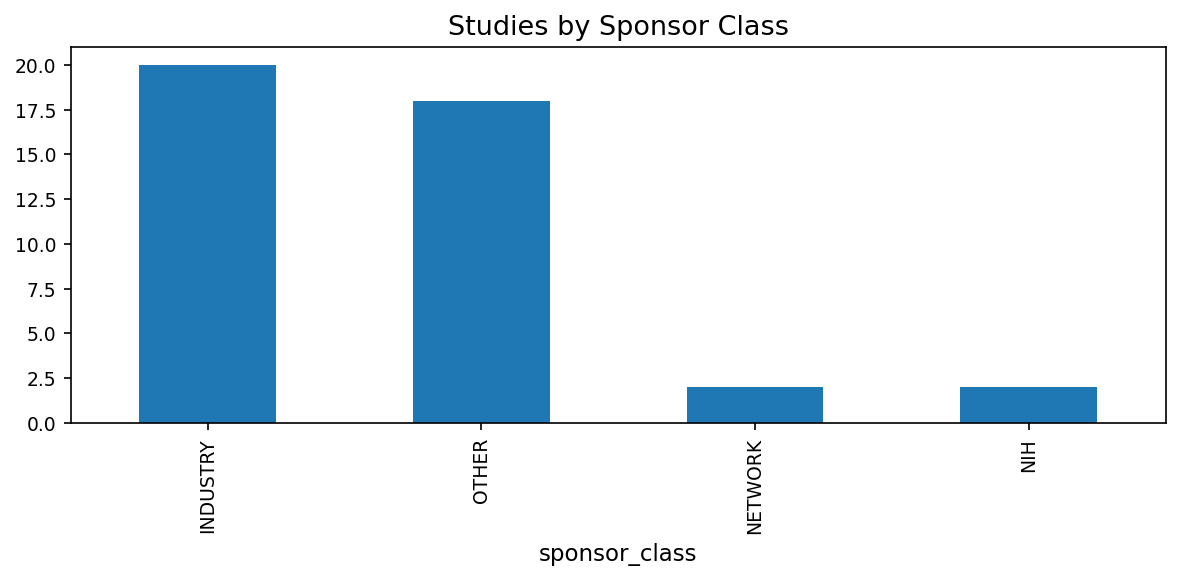

In [246]:
df['sponsor_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Studies by Sponsor Class'
)
# print(set(df['sponsor']))
print("Number of unique sponsors: %s" % len(set(df['sponsor'])))
plt.tight_layout()
plt.show()

## Primary and Total outcomes per study

In [247]:
# n_primary = df['primary_outcomes'].apply(lambda x: -1 if pd.isna(x) else len(json.loads(x)))
print("Number of studies without primary outcomes:", df['primary_outcomes'].isna().sum())

Number of studies without primary outcomes: 0


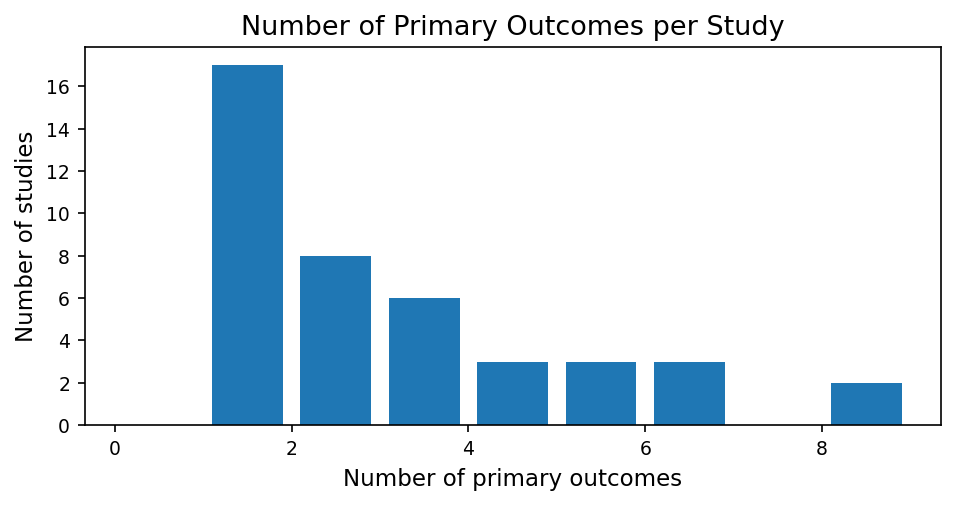

count    42.000000
mean      2.666667
std       1.995931
min       1.000000
25%       1.000000
50%       2.000000
75%       3.750000
max       8.000000
Name: primary_outcomes, dtype: float64


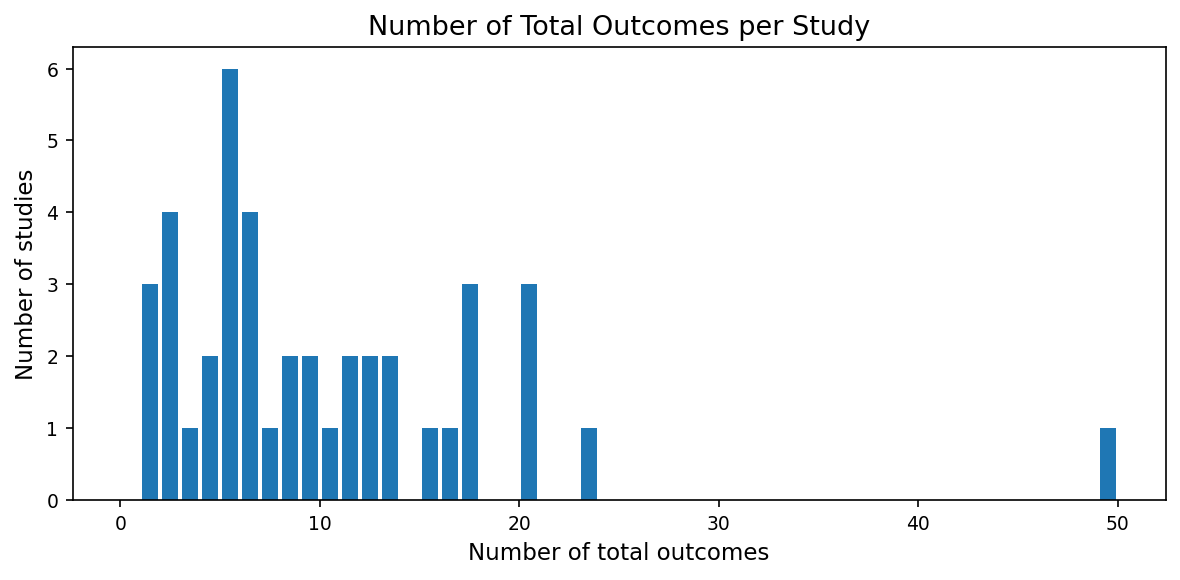

count    42.000000
mean      9.833333
std       8.664243
min       1.000000
25%       5.000000
50%       7.500000
75%      13.000000
max      49.000000
dtype: float64


In [278]:
n_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
n_total = n_primary + df['secondary_outcomes'].dropna().apply(lambda x: len(json.loads(x)))

n_primary.plot(kind='hist', bins=range(0, n_primary.max() + 2), rwidth=0.8, #figsize=(8, 4),
               title='Number of Primary Outcomes per Study', xlabel='Number of primary outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.savefig('../figures/fig_primaryOutcomes.png')
plt.show()
print(n_primary.describe())

n_total.plot(kind='hist', bins=range(0, n_total.max() + 2), rwidth=0.8, figsize=(8, 4),
                 title='Number of Total Outcomes per Study', xlabel='Number of total outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.show()
print(n_total.describe())

In [249]:
# no_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
if (df['primary_outcomes'].isna().sum() > 0):
    d = df[['primary_outcomes', 'status']].copy()
    d['n_primary'] = d['primary_outcomes'].apply(lambda x: len(json.loads(x)))
    d[d['n_primary'] == 0]['status'].value_counts().plot(
        kind='bar', figsize=(8, 4), title='Status of Studies with No Primary Outcomes'
    )
    plt.tight_layout()
    plt.show()
# why are there complete ones with no outocmes??? look into it

In [250]:
df[df['phase2'] == True].shape

(42, 33)

# Enrollment Rate [per study]

In [294]:
enrol_df = df[(df["enrollment"] > 0) ]#& (df['enrollment_type'] == 'ACTUAL')]
print(f"Number of studies with enrollment > 0 and actual start date: {enrol_df.shape[0]}")
start = pd.to_datetime(enrol_df['start_date'], format='mixed')
primary_end = pd.to_datetime(enrol_df['primary_completion_date'], format='mixed')
last_post = pd.to_datetime(enrol_df['last_update_post'], format='mixed')
end = primary_end.where(enrol_df['primary_completion_date_type'] == 'ACTUAL', last_post)
# elapsed = (end - start) 
elapsed = primary_end - start
rate_per_study = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60))


Number of studies with enrollment > 0 and actual start date: 41


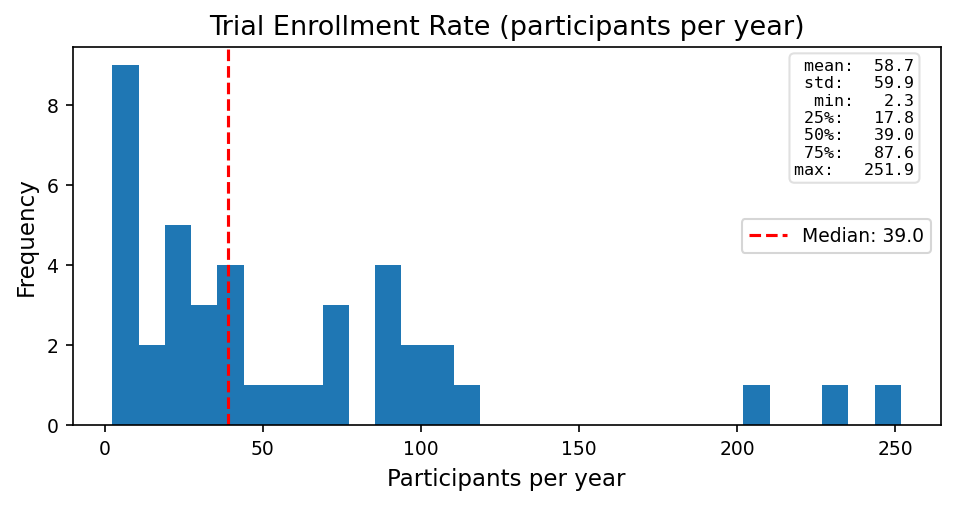

count     41.000000
mean      58.701582
std       59.851698
min        2.343499
25%       17.762951
50%       39.025157
75%       87.586679
max      251.901408
dtype: float64


In [295]:
# rate_per_study = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60)) #/ enrol_df['locations'].apply(json.loads).apply(len)
# rate_per_study.plot(
#     kind='hist',
#     bins=30,
#     figsize=(8, 4),
#     title='Enrollment Rate (participants per year per study)'
# )
# plt.xlabel('Days')
# plt.tight_layout()
# plt.show()
# I stopped normalizing by number of site because some the result were bimodal, i am agussing becuase some studies report site information with lots of details and sites, and others with just one site.
# There also seems to be a bias that some studies are reporting durations differently, or are midway through the duration with many enrolled participants.

rate_per_study = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60)) 
median_rate = rate_per_study.median()
desc = rate_per_study.describe()

stats_text = "\n".join([
    f"mean:  {desc['mean']:.1f}",
    f"std:   {desc['std']:.1f}",
    f"min:   {desc['min']:.1f}",
    f"25%:   {desc['25%']:.1f}",
    f"50%:   {desc['50%']:.1f}",
    f"75%:   {desc['75%']:.1f}",
    f"max:   {desc['max']:.1f}",
])

ax = rate_per_study.plot(
    kind='hist',
    bins=30,
    # figsize=(8, 4),
    title='Trial Enrollment Rate (participants per year)'
)
ax.axvline(median_rate, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_rate:.1f}')
ax.legend()
ax.text(
    0.97, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=8, verticalalignment='top', horizontalalignment='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='lightgray')
)
plt.xlabel('Participants per year')
plt.tight_layout()
plt.savefig('../figures/fig_enrollmentRate.png')
plt.show()
print(desc)

In [276]:
# print(f"ACTUAL primary_completion_date_type: {enrol_df[enrol_df['primary_completion_date_type'] == 'ACTUAL'].shape}")
# print(f"ESTIMATED primary_completion_date_type: {enrol_df[enrol_df['primary_completion_date_type'] == 'ESTIMATED'].shape}")
# enrol_df_2 = df[(df["enrollment"] > 0) & (df['start_date_type'] == 'ESTIMATED')]
# print(f"Number of studies with enrollment > 0 and estimated start date: {enrol_df_2.shape[0]}")
# enrol_df_2[['enrollment', 'start_date', 'primary_completion_date', 'start_date_type', 'primary_completion_date_type', 'last_update_post', 'status']].head(5)
# enrol_df = df[(df["enrollment"] > 0) & (df['enrollment_type'] == 'ACTUAL')]
# print(f"Number of studies with enrollment > 0 and actual enrollment: {enrol_df_2.shape[0]}")
# enrol_df[['nct_id', 'enrollment', 'start_date', 'primary_completion_date', 'start_date_type', 'primary_completion_date_type', 'last_update_post', 'status']].head(20)

# Enrollment Rate [per site]

In [280]:
# start = pd.to_datetime(enrol_df['start_date'], format='mixed')
# primary_end = pd.to_datetime(enrol_df['primary_completion_date'], format='mixed')
# last_post = pd.to_datetime(enrol_df['last_update_post'], format='mixed')
# end = primary_end.where(enrol_df['primary_completion_date_type'] == 'ACTUAL', last_post)
# elapsed = (end - start) 
# elapsed_days = elapsed.dt.total_seconds() / (24 * 3600)
# elapsed_days.plot(
#     kind='hist',
#     bins=30,
#     figsize=(8, 4),
#     title='Elapsed Time (days) from Start to Primary Completion'
# )
# plt.xlabel('Days')
# plt.tight_layout()
# plt.show()
# rate_per_site = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60)) / enrol_df['locations'].apply(len)
# rate_per_site.plot(
#     kind='hist',
#     bins=30,
#     figsize=(8, 4),
#     title='Enrollment Rate (participants per year) from Start to Primary Completion (or most recent update)'
# )
# plt.xlabel('Participants per year')
# plt.tight_layout()
# plt.show()
print(rate_per_site.describe())

count    32.000000
mean      0.980263
std       2.671199
min       0.000191
25%       0.013909
50%       0.036470
75%       0.171733
max      12.586207
dtype: float64
